**1. Palet Warna Hijau (Referensi Global)**

In [16]:
# ── Definisi palet warna hijau — jalankan sekali di awal ─────────────────────
# Gunakan variabel ini di SEMUA cell visualisasi di bawah

HIJAU = {
    "gelap"  : "#1B4332",   # hijau tua — judul, aksen kuat
    "utama"  : "#2D6A4F",   # hijau utama — bar/area dominan
    "sedang" : "#52B788",   # hijau sedang — elemen sekunder
    "muda"   : "#95D5B2",   # hijau muda — latar/gradient ringan
    "pale"   : "#D8F3DC",   # hijau pucat — background panel
    "aksen1" : "#40916C",   # varian 1 — bar kedua
    "aksen2" : "#74C69D",   # varian 2 — bar ketiga
    "kuning" : "#F7B731",   # kontras kuning — garis mean/median
    "merah"  : "#E84855",   # kontras merah — highlight outlier/negatif
    "abu"    : "#6C757D",   # abu netral — teks sekunder
}

# Palet urut untuk bar/pie chart multi-kategori
PALET_HIJAU = [
    "#1B4332", "#2D6A4F", "#40916C",
    "#52B788", "#74C69D", "#95D5B2",
]

# Palet sekuensial Matplotlib & Seaborn
CMAP_SEQ    = "Greens"     # untuk colormap sekuensial
CMAP_DIV    = "RdYlGn"    # untuk colormap diverging
SNS_PALET   = "dark:green" # seaborn palette

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({
    "figure.facecolor" : "#F9FBF9",
    "axes.facecolor"   : "#F0F7F1",
    "axes.edgecolor"   : "#C8E6C9",
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "axes.labelcolor"  : "#1B4332",
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "xtick.color"      : "#2D6A4F",
    "ytick.color"      : "#2D6A4F",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.spines.left" : True,
    "axes.spines.bottom": True,
    "grid.color"       : "#C8E6C9",
    "grid.alpha"       : 0.5,
    "font.family"      : "sans-serif",
    "text.color"       : "#1B4332",
})

sns.set_theme(style="whitegrid", palette=PALET_HIJAU)

print("✅ Palet hijau & konfigurasi matplotlib siap!")
print(f"   Warna utama : {HIJAU['utama']}")
print(f"   Warna gelap : {HIJAU['gelap']}")
print(f"   Colormap    : {CMAP_SEQ}")

✅ Palet hijau & konfigurasi matplotlib siap!
   Warna utama : #2D6A4F
   Warna gelap : #1B4332
   Colormap    : Greens



**2. Setup & Import**

In [17]:
import pandas as pd
import numpy as np
import re
from collections import Counter

print("✅ Import selesai!")

✅ Import selesai!


**3. Gathering Data**

In [18]:
df_food  = pd.read_csv("food_utama.csv")
df_slang = pd.read_csv("slang_utama.csv")
df_synth = pd.read_csv("chatkasir_synthetic.csv")

print("=" * 60)
print("  GATHERING DATA — Ringkasan Awal Ketiga Dataset")
print("=" * 60)
datasets = {
    "food_utama.csv"         : df_food,
    "slang_utama.csv"        : df_slang,
    "chatkasir_synthetic.csv": df_synth,
}
for nama, df in datasets.items():
    print(f"\n📂 {nama}")
    print(f"   Baris  : {len(df):,}")
    print(f"   Kolom  : {df.columns.tolist()}")
    print(f"   Dtypes : {df.dtypes.to_dict()}")

print("\n✅ Gathering selesai!")

  GATHERING DATA — Ringkasan Awal Ketiga Dataset

📂 food_utama.csv
   Baris  : 18,558
   Kolom  : ['name']
   Dtypes : {'name': dtype('O')}

📂 slang_utama.csv
   Baris  : 1,231
   Kolom  : ['slang', 'formal']
   Dtypes : {'slang': dtype('O'), 'formal': dtype('O')}

📂 chatkasir_synthetic.csv
   Baris  : 100,000
   Kolom  : ['input_text', 'product', 'quantity', 'price_satuan', 'pattern']
   Dtypes : {'input_text': dtype('O'), 'product': dtype('O'), 'quantity': dtype('O'), 'price_satuan': dtype('int64'), 'pattern': dtype('int64')}

✅ Gathering selesai!


**4. Assessing Data**

In [19]:
def assess_dataset(df, nama):
    print(f"\n{'='*60}")
    print(f"  ASSESSING: {nama}")
    print(f"{'='*60}")
    print(f"\n[1] Shape       : {df.shape}")
    print(f"\n[2] Missing Value:")
    mv  = df.isnull().sum()
    pct = (mv / len(df) * 100).round(2)
    print(pd.DataFrame({"Jumlah": mv, "Persen (%)": pct}))
    print(f"\n[3] Duplikat    : {df.duplicated().sum()} baris")
    print(f"\n[4] Tipe Data:")
    print(df.dtypes)
    num = df.select_dtypes(include="number")
    if len(num.columns):
        print(f"\n[5] Statistik Numerik:")
        print(num.describe().round(2))
    print(f"\n[6] Preview 3 baris:")
    print(df.head(3).to_string())

assess_dataset(df_food,  "food_utama.csv")
assess_dataset(df_slang, "slang_utama.csv")
assess_dataset(df_synth, "chatkasir_synthetic.csv")


  ASSESSING: food_utama.csv

[1] Shape       : (18558, 1)

[2] Missing Value:
      Jumlah  Persen (%)
name       0         0.0

[3] Duplikat    : 0 baris

[4] Tipe Data:
name    object
dtype: object

[6] Preview 3 baris:
          name
0         abon
1    abon ayam
2  abon burger

  ASSESSING: slang_utama.csv

[1] Shape       : (1231, 2)

[2] Missing Value:
        Jumlah  Persen (%)
slang        0         0.0
formal       0         0.0

[3] Duplikat    : 0 baris

[4] Tipe Data:
slang     object
formal    object
dtype: object

[6] Preview 3 baris:
      slang   formal
0        aa    kakak
1   abanggg    abang
2  abanggku  abangku

  ASSESSING: chatkasir_synthetic.csv

[1] Shape       : (100000, 5)

[2] Missing Value:
              Jumlah  Persen (%)
input_text         0         0.0
product            0         0.0
quantity           0         0.0
price_satuan       0         0.0
pattern            0         0.0

[3] Duplikat    : 2 baris

[4] Tipe Data:
input_text      object
product

**5. Cleaning Data**

In [20]:
print("=" * 60)
print("  CLEANING REPORT — ChatKasir Dataset")
print("=" * 60)

# ── [A] FOOD ──────────────────────────────────────────────────────────────────
df_food_clean = df_food.copy()
df_food_clean["name"]      = df_food_clean["name"].str.strip().str.lower()
df_food_clean["name_clean"]= df_food_clean["name"]

PETA_KATEGORI = {
    "nasi": "Nasi", "mie": "Mie & Pasta", "spaghetti": "Mie & Pasta",
    "pasta": "Mie & Pasta", "ayam": "Ayam", "chicken": "Ayam",
    "ikan": "Seafood", "udang": "Seafood", "kepiting": "Seafood",
    "cumi": "Seafood", "es": "Minuman Dingin", "ice": "Minuman Dingin",
    "iced": "Minuman Dingin", "kopi": "Kopi", "coffee": "Kopi",
    "teh": "Teh", "juice": "Jus & Smoothie", "jus": "Jus & Smoothie",
    "smoothie": "Jus & Smoothie", "roti": "Roti & Bakery",
    "bolu": "Roti & Bakery", "cake": "Roti & Bakery",
    "donat": "Roti & Bakery", "bakso": "Bakso & Soto",
    "soto": "Bakso & Soto", "sop": "Bakso & Soto",
    "sup": "Bakso & Soto", "pisang": "Buah & Dessert",
    "strawberry": "Buah & Dessert", "mangga": "Buah & Dessert",
    "seblak": "Jajanan", "cireng": "Jajanan", "batagor": "Jajanan",
    "siomay": "Jajanan", "beef": "Daging Sapi", "sapi": "Daging Sapi",
    "steak": "Daging Sapi", "kacang": "Camilan", "keripik": "Camilan",
    "chips": "Camilan", "hot": "Minuman Panas", "choco": "Minuman Panas",
    "chocolate": "Minuman Panas", "martabak": "Jajanan",
    "tahu": "Jajanan", "sosis": "Camilan",
}

df_food_clean["kategori"]     = df_food_clean["name_clean"].apply(
    lambda n: PETA_KATEGORI.get(n.split()[0], "Lainnya")
)
df_food_clean["panjang_nama"] = df_food_clean["name_clean"].apply(
    lambda n: len(n.split())
)
print(f"\n📌 [A] food_utama.csv")
print(f"  ✔ Standarisasi nama     : selesai")
print(f"  ✔ Kolom 'kategori'      : {df_food_clean['kategori'].nunique()} kategori")
print(f"  ✔ Kolom 'panjang_nama'  : ditambahkan")
print(f"  ✔ Missing value         : {df_food_clean.isnull().sum().sum()}")
print(f"  ✔ Duplikat              : {df_food_clean.duplicated().sum()}")
print(f"  ✔ Final shape           : {df_food_clean.shape}")

# ── [B] SLANG (Dataset Terbaru) ───────────────────────────────────────────────
df_slang_clean = df_slang.copy()
df_slang_clean["slang"]  = df_slang_clean["slang"].str.strip().str.lower()
df_slang_clean["formal"] = df_slang_clean["formal"].str.strip().str.lower()
df_slang_clean["panjang_slang"]   = df_slang_clean["slang"].str.len()
df_slang_clean["panjang_formal"]  = df_slang_clean["formal"].str.len()
df_slang_clean["selisih_panjang"] = (
    df_slang_clean["panjang_formal"] - df_slang_clean["panjang_slang"]
)
df_slang_clean["tipe"] = df_slang_clean["selisih_panjang"].apply(
    lambda s: "Disingkat" if s > 0 else ("Sama" if s == 0 else "Diperpanjang")
)

# Kata-kata bisnis baru di dataset terbaru
kata_bisnis_baru = ["order", "pickup", "cod", "ttl", "mau", "pesen dong", "request"]
bisnis_baru_df = df_slang_clean[
    df_slang_clean["slang"].isin(kata_bisnis_baru)
][["slang", "formal"]]

print(f"\n📌 [B] slang_utama.csv (Dataset Terbaru)")
print(f"  ✔ Standarisasi teks     : selesai")
print(f"  ✔ Missing value         : {df_slang_clean.isnull().sum().sum()}")
print(f"  ✔ Duplikat              : {df_slang_clean.duplicated().sum()}")
print(f"  ✔ Final shape           : {df_slang_clean.shape}")
print(f"  ✔ Distribusi tipe:")
print(df_slang_clean["tipe"].value_counts().to_string())
print(f"\n  🆕 Kosakata bisnis baru yang terdeteksi:")
print(bisnis_baru_df.to_string(index=False))

# ── [C] SYNTHETIC ─────────────────────────────────────────────────────────────
df_synth_clean = df_synth.copy()
n_before = len(df_synth_clean)
df_synth_clean = df_synth_clean.drop_duplicates().reset_index(drop=True)

HARGA_MIN_VALID = 5_000
HARGA_MAX_VALID = 500_000

df_synth_clean["harga_eksplisit"] = df_synth_clean["price_satuan"] != -1
df_synth_clean["harga_valid"]     = (
    (df_synth_clean["price_satuan"] >= HARGA_MIN_VALID) &
    (df_synth_clean["price_satuan"] <= HARGA_MAX_VALID)
)
df_synth_clean["harga_outlier"]   = (
    df_synth_clean["harga_eksplisit"] & ~df_synth_clean["harga_valid"]
)
df_synth_clean["multi_produk"]    = df_synth_clean["product"].str.contains(
    " & ", na=False
)
df_synth_clean["qty_numerik"]     = pd.to_numeric(
    df_synth_clean["quantity"], errors="coerce"
).notna()

def segmen_harga(row):
    if not row["harga_valid"]:
        return "Tidak Disebutkan / Outlier"
    h = row["price_satuan"]
    if h < 20_000:    return "Murah (< 20rb)"
    elif h < 50_000:  return "Sedang (20rb–50rb)"
    elif h < 100_000: return "Agak Mahal (50rb–100rb)"
    else:             return "Mahal (≥ 100rb)"

df_synth_clean["segmen_harga"] = df_synth_clean.apply(segmen_harga, axis=1)

n_hv   = df_synth_clean["harga_valid"].sum()
n_out  = df_synth_clean["harga_outlier"].sum()
n_imp  = (~df_synth_clean["harga_eksplisit"]).sum()

print(f"\n📌 [C] chatkasir_synthetic.csv")
print(f"  ✔ Duplikat dihapus          : {n_before - len(df_synth_clean)} baris")
print(f"  ✔ Harga eksplisit           : {df_synth_clean['harga_eksplisit'].sum():,}")
print(f"  ✔ Harga valid (5rb–500rb)   : {n_hv:,} ({n_hv/len(df_synth_clean)*100:.1f}%)")
print(f"  ✔ Harga outlier (>500rb)    : {n_out:,}")
print(f"  ✔ Harga tidak disebutkan    : {n_imp:,} ({n_imp/len(df_synth_clean)*100:.1f}%)")
print(f"  ✔ Multi-produk              : {df_synth_clean['multi_produk'].sum():,}")
print(f"  ✔ Final shape               : {df_synth_clean.shape}")

print("\n" + "="*60)
print("  ✅ Cleaning selesai!")
print("="*60)

  CLEANING REPORT — ChatKasir Dataset

📌 [A] food_utama.csv
  ✔ Standarisasi nama     : selesai
  ✔ Kolom 'kategori'      : 16 kategori
  ✔ Kolom 'panjang_nama'  : ditambahkan
  ✔ Missing value         : 0
  ✔ Duplikat              : 0
  ✔ Final shape           : (18558, 4)

📌 [B] slang_utama.csv (Dataset Terbaru)
  ✔ Standarisasi teks     : selesai
  ✔ Missing value         : 0
  ✔ Duplikat              : 0
  ✔ Final shape           : (1231, 6)
  ✔ Distribusi tipe:
tipe
Disingkat       767
Diperpanjang    288
Sama            176

  🆕 Kosakata bisnis baru yang terdeteksi:
     slang          formal
pesen dong      pesan dong
     order           pesan
       mau           ingin
   request           pesan
       ttl           total
       cod bayar di tempat
    pickup   ambil sendiri

📌 [C] chatkasir_synthetic.csv
  ✔ Duplikat dihapus          : 2 baris
  ✔ Harga eksplisit           : 66,070
  ✔ Harga valid (5rb–500rb)   : 43,227 (43.2%)
  ✔ Harga outlier (>500rb)    : 22,843
  ✔ Harga

**6. Perumusan 7 Pertanyaan Bisnis**

In [21]:
pertanyaan_bisnis = [
    {
        "Kode"       : "PB-1",
        "4W"         : "What",
        "Pertanyaan" : "Apa 20 produk makanan yang paling sering muncul dalam percakapan pesanan?",
        "Metrik"     : "Frekuensi kemunculan nama produk di kolom 'product' (split multi-produk)",
        "Action"     : "Pemilik UMKM prioritaskan stok & promo produk hero",
        "Dataset"    : "chatkasir_synthetic.csv",
    },
    {
        "Kode"       : "PB-2",
        "4W"         : "What",
        "Pertanyaan" : "Berapa nilai rata-rata dan median harga satuan produk eksplisit?",
        "Metrik"     : "Mean & median price_satuan (filter: 5rb–500rb)",
        "Action"     : "Tetapkan HPP & estimasi pendapatan harian",
        "Dataset"    : "chatkasir_synthetic.csv",
    },
    {
        "Kode"       : "PB-3",
        "4W"         : "What",
        "Pertanyaan" : "Bagaimana distribusi segmentasi harga dalam 4 kelompok?",
        "Metrik"     : "Proporsi & frekuensi per segmen (Murah/Sedang/Agak Mahal/Mahal)",
        "Action"     : "Rancang strategi bundling sesuai segmen dominan",
        "Dataset"    : "chatkasir_synthetic.csv",
    },
    {
        "Kode"       : "PB-4",
        "4W"         : "Why",
        "Pertanyaan" : "Mengapa ~57% pesanan tidak menyebut harga eksplisit?",
        "Metrik"     : "% harga eksplisit/implisit per pola percakapan (pattern 1–4)",
        "Action"     : "Tim AI bangun mekanisme fallback harga dari database",
        "Dataset"    : "chatkasir_synthetic.csv",
    },
    {
        "Kode"       : "PB-5",
        "4W"         : "What",
        "Pertanyaan" : "Kata slang apa yang paling aktif dalam percakapan pesanan UMKM?",
        "Metrik"     : "Frekuensi kemunculan slang dari 10.000 sampel teks obrolan",
        "Action"     : "Prioritaskan 30 slang teratas di pipeline normalisasi AI",
        "Dataset"    : "slang_utama.csv + chatkasir_synthetic.csv",
    },
    {
        "Kode"       : "PB-6",
        "4W"         : "What",
        "Pertanyaan" : "Bagaimana distribusi tipe kuantitas pesanan (angka vs teks)?",
        "Metrik"     : "Proporsi qty numerik vs deskriptif; top 12 ekspresi teks",
        "Action"     : "Bangun kamus konversi teks→angka sebelum masuk model NLP",
        "Dataset"    : "chatkasir_synthetic.csv",
    },
    {
        "Kode"       : "PB-7",
        "4W"         : "What",
        "Pertanyaan" : "Kategori masakan apa yang mendominasi database produk makanan?",
        "Metrik"     : "Jumlah produk & rata-rata panjang nama per kategori",
        "Action"     : "Perluas dataset kategori under-represented untuk model NLP",
        "Dataset"    : "food_utama.csv",
    },
]

df_pb = pd.DataFrame(pertanyaan_bisnis)
print("=" * 70)
print("  7 PERTANYAAN BISNIS — ChatKasir · SMART + 4W")
print("=" * 70)
for _, r in df_pb.iterrows():
    print(f"\n[{r['Kode']} | {r['4W']}]")
    print(f"  ❓ {r['Pertanyaan']}")
    print(f"  📏 Metrik  : {r['Metrik']}")
    print(f"  🎯 Aksi    : {r['Action']}")
print(f"\n✅ {len(df_pb)} pertanyaan bisnis SMART terdefinisi!")

  7 PERTANYAAN BISNIS — ChatKasir · SMART + 4W

[PB-1 | What]
  ❓ Apa 20 produk makanan yang paling sering muncul dalam percakapan pesanan?
  📏 Metrik  : Frekuensi kemunculan nama produk di kolom 'product' (split multi-produk)
  🎯 Aksi    : Pemilik UMKM prioritaskan stok & promo produk hero

[PB-2 | What]
  ❓ Berapa nilai rata-rata dan median harga satuan produk eksplisit?
  📏 Metrik  : Mean & median price_satuan (filter: 5rb–500rb)
  🎯 Aksi    : Tetapkan HPP & estimasi pendapatan harian

[PB-3 | What]
  ❓ Bagaimana distribusi segmentasi harga dalam 4 kelompok?
  📏 Metrik  : Proporsi & frekuensi per segmen (Murah/Sedang/Agak Mahal/Mahal)
  🎯 Aksi    : Rancang strategi bundling sesuai segmen dominan

[PB-4 | Why]
  ❓ Mengapa ~57% pesanan tidak menyebut harga eksplisit?
  📏 Metrik  : % harga eksplisit/implisit per pola percakapan (pattern 1–4)
  🎯 Aksi    : Tim AI bangun mekanisme fallback harga dari database

[PB-5 | What]
  ❓ Kata slang apa yang paling aktif dalam percakapan pesanan UM

**7. Visualisasi PB-1 (Produk Terlaris)**

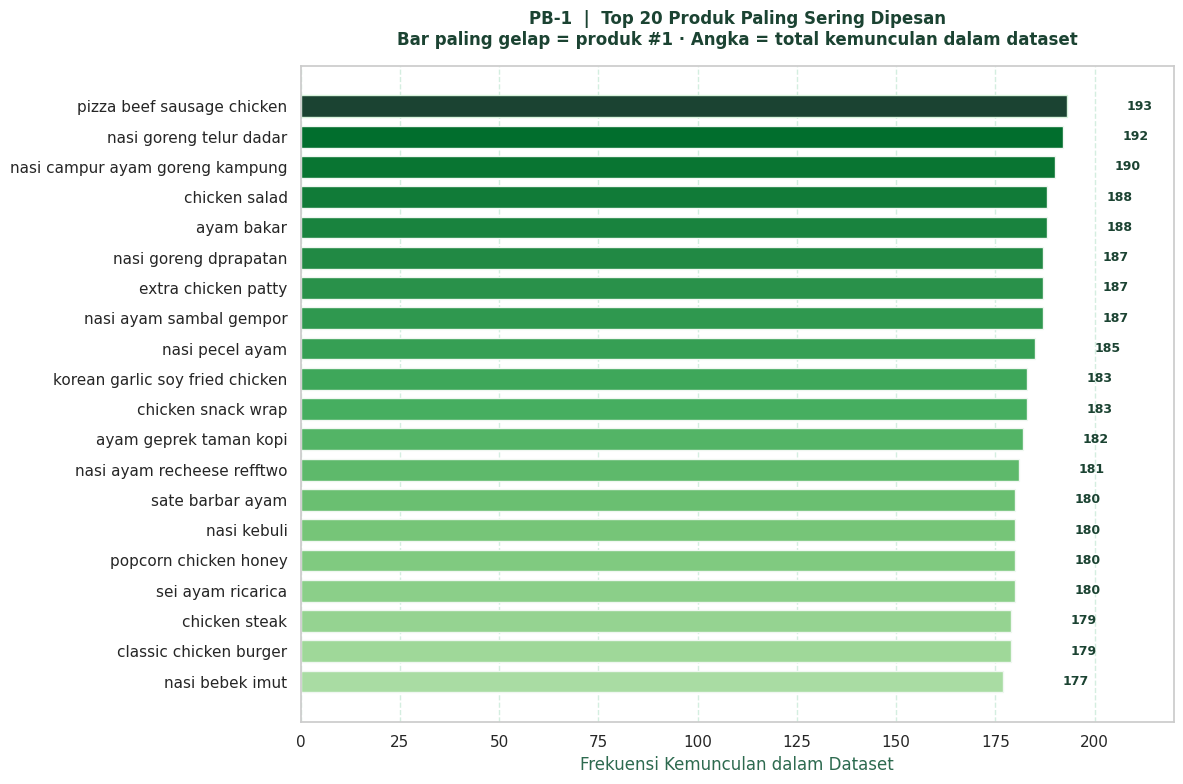

✅ PB-1 | Produk terlaris: 'pizza beef sausage chicken' (193 kemunculan)


In [22]:
# ── PB-1: Horizontal Bar Chart — Top 20 Produk ────────────────────────────────
semua_produk = (
    df_synth_clean["product"]
    .dropna()
    .apply(lambda x: [p.strip().lower() for p in x.split(" & ")])
    .explode()
    .str.strip()
)
top20 = semua_produk.value_counts().head(20).reset_index()
top20.columns = ["Produk", "Frekuensi"]
top20 = top20.sort_values("Frekuensi", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

# Warna: gradasi hijau, bar tertinggi lebih gelap
n = len(top20)
colors = [
    plt.cm.Greens(0.35 + 0.55 * i / (n - 1)) for i in range(n)
]
bars = ax.barh(
    top20["Produk"], top20["Frekuensi"],
    color=colors, edgecolor="#F0F7F1", height=0.72
)

# Label angka + highlight bar tertinggi
bars[-1].set_facecolor(HIJAU["gelap"])
bars[-1].set_edgecolor("#D8F3DC")
for bar, val in zip(bars, top20["Frekuensi"]):
    ax.text(
        bar.get_width() + 15,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center", fontsize=9, fontweight="bold",
        color=HIJAU["gelap"],
    )

ax.set_xlim(0, top20["Frekuensi"].max() * 1.14)
ax.set_title(
    "PB-1  |  Top 20 Produk Paling Sering Dipesan\n"
    "Bar paling gelap = produk #1 · Angka = total kemunculan dalam dataset",
    pad=15, color=HIJAU["gelap"],
)
ax.set_xlabel("Frekuensi Kemunculan dalam Dataset", color=HIJAU["utama"])
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.4, linestyle="--", color=HIJAU["muda"])
ax.grid(axis="y", alpha=0)

fig.tight_layout()
plt.savefig("pb1_produk_terlaris.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

produk_1 = top20.iloc[-1]["Produk"]
freq_1   = top20.iloc[-1]["Frekuensi"]
print(f"✅ PB-1 | Produk terlaris: '{produk_1}' ({freq_1:,} kemunculan)")

**8. Visualisasi PB-2 & PB-3 (Harga)**

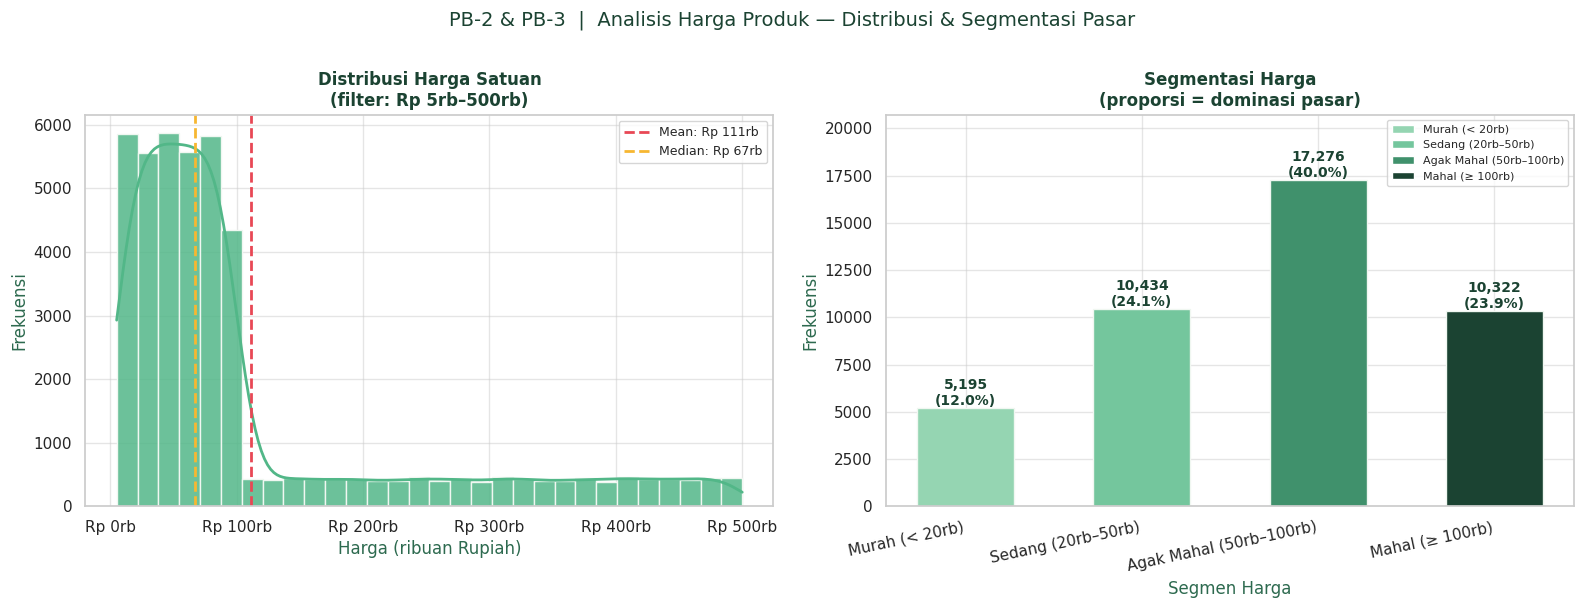

✅ PB-2 | Mean: Rp 111,379 | Median: Rp 67,000
✅ PB-3 | Segmen dominan: Agak Mahal (50rb–100rb)


In [23]:
# ── PB-2 & PB-3: Histogram + Segmen Harga ─────────────────────────────────────
URUTAN_SEGMEN = [
    "Murah (< 20rb)", "Sedang (20rb–50rb)",
    "Agak Mahal (50rb–100rb)", "Mahal (≥ 100rb)",
]
WARNA_SEGMEN = [
    HIJAU["muda"], HIJAU["aksen2"], HIJAU["aksen1"], HIJAU["gelap"]
]

df_harga_valid = df_synth_clean[df_synth_clean["harga_valid"]].copy()
mean_h   = df_harga_valid["price_satuan"].mean()
median_h = df_harga_valid["price_satuan"].median()

df_seg = (
    df_harga_valid["segmen_harga"]
    .value_counts()
    .reindex(URUTAN_SEGMEN)
    .fillna(0)
    .reset_index()
)
df_seg.columns = ["Segmen", "Jumlah"]
df_seg["Persen"] = (df_seg["Jumlah"] / df_seg["Jumlah"].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "PB-2 & PB-3  |  Analisis Harga Produk — Distribusi & Segmentasi Pasar",
    fontsize=14, color=HIJAU["gelap"], y=1.01,
)

# ── Kiri: Histogram + KDE (PB-2) ─────────────────────────────────────────────
sns.histplot(
    df_harga_valid["price_satuan"] / 1_000,
    bins=30, kde=True,
    color=HIJAU["sedang"],
    edgecolor="#F0F7F1",
    alpha=0.85,
    ax=axes[0],
    line_kws={"color": HIJAU["gelap"], "linewidth": 2},
)
axes[0].axvline(
    mean_h / 1_000, color=HIJAU["merah"],
    linestyle="--", linewidth=2,
    label=f"Mean: Rp {mean_h/1_000:.0f}rb",
)
axes[0].axvline(
    median_h / 1_000, color=HIJAU["kuning"],
    linestyle="--", linewidth=2,
    label=f"Median: Rp {median_h/1_000:.0f}rb",
)
axes[0].set_title(
    "Distribusi Harga Satuan\n(filter: Rp 5rb–500rb)",
    color=HIJAU["gelap"],
)
axes[0].set_xlabel("Harga (ribuan Rupiah)", color=HIJAU["utama"])
axes[0].set_ylabel("Frekuensi", color=HIJAU["utama"])
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rp {x:.0f}rb")
)

# ── Kanan: Bar Chart Segmen (PB-3) ───────────────────────────────────────────
bars_seg = axes[1].bar(
    df_seg["Segmen"], df_seg["Jumlah"],
    color=WARNA_SEGMEN, edgecolor="#F0F7F1", width=0.55,
)
for bar, row in zip(bars_seg, df_seg.itertuples()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f"{row.Jumlah:,.0f}\n({row.Persen}%)",
        ha="center", fontsize=10, fontweight="bold",
        color=HIJAU["gelap"],
    )
axes[1].set_title(
    "Segmentasi Harga\n(proporsi = dominasi pasar)",
    color=HIJAU["gelap"],
)
axes[1].set_xlabel("Segmen Harga", color=HIJAU["utama"])
axes[1].set_ylabel("Frekuensi", color=HIJAU["utama"])
axes[1].set_ylim(0, df_seg["Jumlah"].max() * 1.2)
plt.setp(axes[1].get_xticklabels(), rotation=12, ha="right")

# Legenda warna segmen
patches = [
    mpatches.Patch(facecolor=c, label=s, edgecolor="white")
    for c, s in zip(WARNA_SEGMEN, URUTAN_SEGMEN)
]
axes[1].legend(handles=patches, fontsize=8, loc="upper right")

fig.tight_layout()
plt.savefig("pb2_pb3_harga.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

seg_dom = df_seg.loc[df_seg["Jumlah"].idxmax(), "Segmen"]
print(f"✅ PB-2 | Mean: Rp {mean_h:,.0f} | Median: Rp {median_h:,.0f}")
print(f"✅ PB-3 | Segmen dominan: {seg_dom}")

**9. Visualisasi PB-4 (Pola & Harga Eksplisit)**

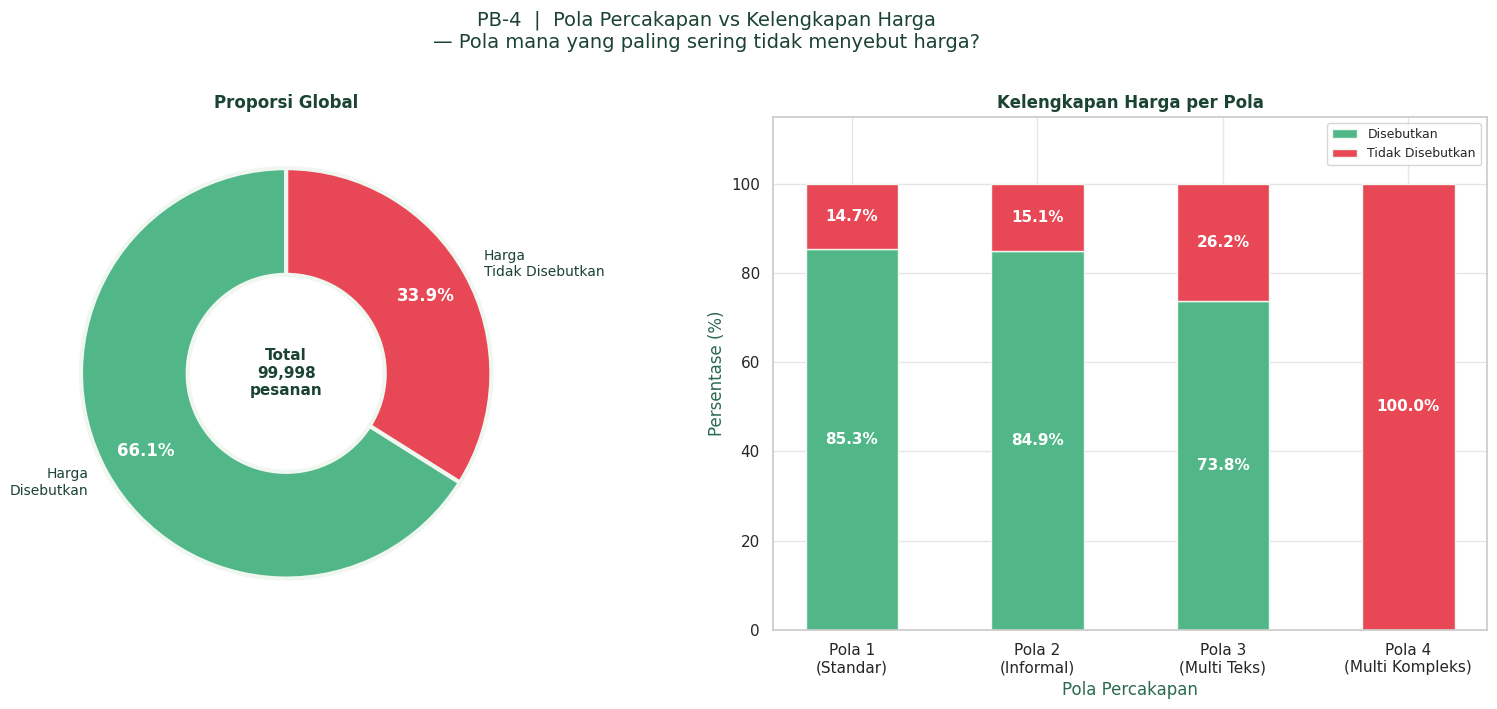

✅ PB-4 | Harga eksplisit: 66.1% | Tidak: 33.9%


In [24]:
# ── PB-4: Donut + Stacked Bar ─────────────────────────────────────────────────
POLA_LABEL = {
    1: "Pola 1\n(Standar)",
    2: "Pola 2\n(Informal)",
    3: "Pola 3\n(Multi Teks)",
    4: "Pola 4\n(Multi Kompleks)",
}

pola_summary = (
    df_synth_clean
    .groupby("pattern")["harga_eksplisit"]
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)
pola_summary.columns = ["Tidak Disebutkan", "Disebutkan"]
pola_summary = pola_summary[["Disebutkan", "Tidak Disebutkan"]]
pola_summary.index = [POLA_LABEL[i] for i in pola_summary.index]

n_eks = df_synth_clean["harga_eksplisit"].sum()
n_imp = (~df_synth_clean["harga_eksplisit"]).sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    "PB-4  |  Pola Percakapan vs Kelengkapan Harga\n"
    "— Pola mana yang paling sering tidak menyebut harga?",
    fontsize=14, color=HIJAU["gelap"], y=1.01,
)

# ── Kiri: Donut global ────────────────────────────────────────────────────────
wedges, texts, autotexts = axes[0].pie(
    [n_eks, n_imp],
    labels=["Harga\nDisebutkan", "Harga\nTidak Disebutkan"],
    autopct="%1.1f%%",
    colors=[HIJAU["sedang"], HIJAU["merah"]],
    startangle=90,
    pctdistance=0.78,
    wedgeprops={
        "width": 0.52,
        "edgecolor": "#F0F7F1",
        "linewidth": 3,
    },
)
for t in texts:
    t.set_color(HIJAU["gelap"])
    t.set_fontsize(10)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight("bold")
    at.set_color("white")

axes[0].set_title("Proporsi Global", color=HIJAU["gelap"])
axes[0].annotate(
    f"Total\n{len(df_synth_clean):,}\npesanan",
    xy=(0, 0), ha="center", va="center",
    fontsize=11, fontweight="bold", color=HIJAU["gelap"],
)

# ── Kanan: Stacked Bar per pola ───────────────────────────────────────────────
pola_reset = pola_summary.reset_index().rename(columns={"index": "Pola"})

bottom_vals = np.zeros(len(pola_reset))
for col_name, warna in [
    ("Disebutkan",      HIJAU["sedang"]),
    ("Tidak Disebutkan", HIJAU["merah"]),
]:
    vals = pola_reset[col_name].values
    bars_stk = axes[1].bar(
        pola_reset.iloc[:, 0], vals,
        bottom=bottom_vals,
        color=warna, edgecolor="#F0F7F1",
        width=0.5, label=col_name,
    )
    # Label dalam bar
    for bar, v, b in zip(bars_stk, vals, bottom_vals):
        if v > 5:
            axes[1].text(
                bar.get_x() + bar.get_width() / 2,
                b + v / 2,
                f"{v:.1f}%",
                ha="center", va="center",
                fontsize=11, fontweight="bold",
                color="white",
            )
    bottom_vals += vals

axes[1].set_title("Kelengkapan Harga per Pola", color=HIJAU["gelap"])
axes[1].set_xlabel("Pola Percakapan", color=HIJAU["utama"])
axes[1].set_ylabel("Persentase (%)", color=HIJAU["utama"])
axes[1].set_ylim(0, 115)
axes[1].legend(loc="upper right", fontsize=9)

fig.tight_layout()
plt.savefig("pb4_pola_harga.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

pct_eks = df_synth_clean["harga_eksplisit"].mean() * 100
print(f"✅ PB-4 | Harga eksplisit: {pct_eks:.1f}% | Tidak: {100-pct_eks:.1f}%")

**10. Hitung Slang Aktif**

In [25]:
# ── Hitung kemunculan slang dengan dataset slang terbaru ─────────────────────
set_slang    = set(df_slang_clean["slang"])
kamus_formal = dict(zip(df_slang_clean["slang"], df_slang_clean["formal"]))

# Sample 10.000 baris teks
sample_teks = df_synth_clean["input_text"].sample(10_000, random_state=42)
semua_kata  = []
for teks in sample_teks:
    bagian_customer = teks.split("[SEP]")[0].lower()
    semua_kata.extend(re.findall(r"\b\w+\b", bagian_customer))

kata_slang_aktif = [k for k in semua_kata if k in set_slang]
counter_slang    = Counter(kata_slang_aktif)

top15_slang = pd.DataFrame(
    counter_slang.most_common(15), columns=["Slang", "Frekuensi"]
)
top15_slang["Formal"] = top15_slang["Slang"].map(kamus_formal)

print(f"Total kemunculan kata slang (10.000 sampel): {len(kata_slang_aktif):,}")
print(f"Unik kata slang yang aktif: {len(counter_slang):,}")
print()
print("── Top 15 Kata Slang Paling Aktif ───────────────────────")
for slang, freq in counter_slang.most_common(15):
    formal = kamus_formal.get(slang, "-")
    print(f"  '{slang}' → '{formal}' : {freq}×")

# Tampilkan kosakata bisnis baru yang aktif
kata_bisnis = ["order", "pickup", "cod", "ttl", "mnt", "krm", "ongkir"]
print("\n── Kosakata Bisnis Baru dalam Dataset Slang ─────────────")
for k in kata_bisnis:
    if k in counter_slang:
        print(f"  '{k}' → '{kamus_formal.get(k, '-')}' : {counter_slang[k]}×")
    else:
        print(f"  '{k}' → (tidak ditemukan dalam 10.000 sampel)")

Total kemunculan kata slang (10.000 sampel): 11,666
Unik kata slang yang aktif: 158

── Top 15 Kata Slang Paling Aktif ───────────────────────
  'mau' → 'ingin' : 1796×
  'pesen' → 'pesan' : 1539×
  'kak' → 'kakak' : 936×
  'order' → 'pesan' : 875×
  'pake' → 'pakai' : 821×
  'min' → 'admin' : 539×
  'bang' → 'abang' : 529×
  'mbak' → 'mbak-mbak' : 501×
  'pack' → 'bungkus' : 475×
  'pak' → 'bapak' : 386×
  'bu' → 'ibu' : 380×
  'pedes' → 'pedas' : 350×
  'bungkusin' → 'bungkuskan' : 285×
  'minta' → 'meminta' : 285×
  'dibikin' → 'dibuat' : 224×

── Kosakata Bisnis Baru dalam Dataset Slang ─────────────
  'order' → 'pesan' : 875×
  'pickup' → (tidak ditemukan dalam 10.000 sampel)
  'cod' → (tidak ditemukan dalam 10.000 sampel)
  'ttl' → (tidak ditemukan dalam 10.000 sampel)
  'mnt' → 'minta' : 1×
  'krm' → (tidak ditemukan dalam 10.000 sampel)
  'ongkir' → (tidak ditemukan dalam 10.000 sampel)


**11. Visualisasi PB-5 (Slang Aktif)**

In [ ]:
# ── PB-5: Horizontal Bar Chart dengan label formal ────────────────────────────
top15_sorted = top15_slang.sort_values("Frekuensi", ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))

n = len(top15_sorted)
colors_slang = [plt.cm.Greens(0.3 + 0.6 * i / (n - 1)) for i in range(n)]

bars = ax.barh(
    top15_sorted["Slang"], top15_sorted["Frekuensi"],
    color=colors_slang, edgecolor="#F0F7F1", height=0.68,
)

# Label: frekuensi + padanan formal di luar bar
for bar, (_, row) in zip(bars, top15_sorted.iterrows()):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"  → '{row['Formal']}'  ({row['Frekuensi']}×)",
        va="center", fontsize=9.5, color=HIJAU["gelap"],
    )

ax.set_xlim(0, top15_sorted["Frekuensi"].max() * 1.5)
ax.set_title(
    "PB-5  |  Top 15 Kata Slang Paling Aktif dalam Percakapan Pesanan\n"
    "Teks = padanan formal · Semakin panjang bar → prioritas normalisasi AI lebih tinggi",
    color=HIJAU["gelap"], pad=15,
)
ax.set_xlabel("Frekuensi Kemunculan (dari 10.000 sampel teks)", color=HIJAU["utama"])
ax.set_ylabel("Kata Slang", color=HIJAU["utama"])
ax.grid(axis="x", alpha=0.35, linestyle="--", color=HIJAU["muda"])

fig.tight_layout()
plt.savefig("pb5_slang_aktif.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

slang_1  = top15_sorted.iloc[-1]["Slang"]
formal_1 = top15_sorted.iloc[-1]["Formal"]
print(f"✅ PB-5 | Slang paling aktif: '{slang_1}' → '{formal_1}'")

**12. Visualisasi PB-6 & PB-7**

In [ ]:
# ── PB-6 & PB-7: 4 grafik dalam 2×2 grid ─────────────────────────────────────
qty_teks    = df_synth_clean.loc[~df_synth_clean["qty_numerik"], "quantity"]
qty_tunggal = qty_teks[~qty_teks.str.contains("&", na=False)]
top_qty     = qty_tunggal.value_counts().head(12).reset_index()
top_qty.columns = ["Ekspresi", "Frekuensi"]

df_kat   = df_food_clean["kategori"].value_counts().reset_index()
df_kat.columns = ["Kategori", "Jumlah"]
df_kat   = df_kat.sort_values("Jumlah", ascending=True)

mean_pjg = (
    df_food_clean.groupby("kategori")["panjang_nama"]
    .mean().round(1).reset_index()
)
mean_pjg.columns = ["Kategori", "Rata-rata Kata"]
mean_pjg = mean_pjg.sort_values("Rata-rata Kata", ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle(
    "PB-6 & PB-7  |  Kuantitas Pesanan & Kategori Produk Makanan",
    fontsize=15, color=HIJAU["gelap"], y=1.01,
)

# ── (1) Donut: proporsi qty numerik vs teks ───────────────────────────────────
qty_num  = int(df_synth_clean["qty_numerik"].sum())
qty_teks_n = int((~df_synth_clean["qty_numerik"]).sum())
wedges_q, texts_q, at_q = axes[0, 0].pie(
    [qty_num, qty_teks_n],
    labels=["Numerik\n(angka)", "Deskriptif\n(teks)"],
    autopct="%1.1f%%",
    colors=[HIJAU["sedang"], HIJAU["kuning"]],
    startangle=90,
    pctdistance=0.78,
    wedgeprops={"width": 0.52, "edgecolor": "#F0F7F1", "linewidth": 3},
)
for t in texts_q:
    t.set_color(HIJAU["gelap"])
    t.set_fontsize(10)
for at in at_q:
    at.set_fontsize(13)
    at.set_fontweight("bold")
    at.set_color("white")
axes[0, 0].set_title("PB-6a | Proporsi Tipe Kuantitas", color=HIJAU["gelap"])
axes[0, 0].annotate(
    "Kuantitas\nPesanan",
    xy=(0, 0), ha="center", va="center",
    fontsize=11, fontweight="bold", color=HIJAU["gelap"],
)

# ── (2) Horizontal bar: top ekspresi kuantitas teks ──────────────────────────
top_qty_s = top_qty.sort_values("Frekuensi", ascending=True)
n2        = len(top_qty_s)
colors_q  = [plt.cm.YlGn(0.35 + 0.55 * i / max(n2 - 1, 1)) for i in range(n2)]
bars_q    = axes[0, 1].barh(
    top_qty_s["Ekspresi"], top_qty_s["Frekuensi"],
    color=colors_q, edgecolor="#F0F7F1", height=0.68,
)
for bar, val in zip(bars_q, top_qty_s["Frekuensi"]):
    axes[0, 1].text(
        bar.get_width() + 30,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}", va="center", fontsize=9, fontweight="bold",
        color=HIJAU["gelap"],
    )
axes[0, 1].set_title(
    "PB-6b | Top 12 Ekspresi Kuantitas Deskriptif\n"
    "(wajib dikonversi ke angka oleh model AI)",
    color=HIJAU["gelap"],
)
axes[0, 1].set_xlabel("Frekuensi", color=HIJAU["utama"])
axes[0, 1].set_xlim(0, top_qty_s["Frekuensi"].max() * 1.18)

# ── (3) Horizontal bar: jumlah produk per kategori ───────────────────────────
n3       = len(df_kat)
colors3  = [plt.cm.Greens(0.3 + 0.6 * i / max(n3 - 1, 1)) for i in range(n3)]
bars_kat = axes[1, 0].barh(
    df_kat["Kategori"], df_kat["Jumlah"],
    color=colors3, edgecolor="#F0F7F1", height=0.68,
)
for bar, val in zip(bars_kat, df_kat["Jumlah"]):
    axes[1, 0].text(
        bar.get_width() + 30,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}", va="center", fontsize=9, fontweight="bold",
        color=HIJAU["gelap"],
    )
axes[1, 0].set_title(
    "PB-7a | Jumlah Produk per Kategori Masakan\n"
    "('Lainnya' = produk belum terklasifikasi)",
    color=HIJAU["gelap"],
)
axes[1, 0].set_xlabel("Jumlah Nama Produk", color=HIJAU["utama"])
axes[1, 0].set_xlim(0, df_kat["Jumlah"].max() * 1.15)

# ── (4) Horizontal bar: rata-rata panjang nama ────────────────────────────────
n4       = len(mean_pjg)
colors4  = [plt.cm.BuGn(0.3 + 0.6 * i / max(n4 - 1, 1)) for i in range(n4)]
bars_pjg = axes[1, 1].barh(
    mean_pjg["Kategori"], mean_pjg["Rata-rata Kata"],
    color=colors4, edgecolor="#F0F7F1", height=0.68,
)
for bar, val in zip(bars_pjg, mean_pjg["Rata-rata Kata"]):
    axes[1, 1].text(
        bar.get_width() + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f"{val} kata", va="center", fontsize=9, fontweight="bold",
        color=HIJAU["gelap"],
    )
axes[1, 1].set_title(
    "PB-7b | Rata-rata Panjang Nama Produk per Kategori\n"
    "(makin panjang → makin kompleks diekstrak model)",
    color=HIJAU["gelap"],
)
axes[1, 1].set_xlabel("Rata-rata Jumlah Kata", color=HIJAU["utama"])
axes[1, 1].set_xlim(0, mean_pjg["Rata-rata Kata"].max() * 1.25)

fig.tight_layout()
plt.savefig("pb6_pb7_kuantitas_kategori.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

pct_teks_qty = (~df_synth_clean["qty_numerik"]).mean() * 100
pct_lainnya  = round(
    df_food_clean[df_food_clean["kategori"] == "Lainnya"].shape[0]
    / len(df_food_clean) * 100, 1
)
print(f"✅ PB-6 | Kuantitas teks: {pct_teks_qty:.1f}%")
print(f"✅ PB-7 | Kategori dominan: {df_kat.iloc[-1]['Kategori']} "
      f"({df_kat.iloc[-1]['Jumlah']:,} produk)")
print(f"✅ PB-7 | Produk 'Lainnya': {pct_lainnya}%")

**13. Explanatory Analysis (Insight Bisnis)**

In [ ]:
# ── Hitung angka kunci ─────────────────────────────────────────────────────────
produk_1    = top20.iloc[-1]["Produk"]
freq_1      = top20.iloc[-1]["Frekuensi"]
mean_rb     = round(mean_h / 1_000)
median_rb   = round(median_h / 1_000)
seg_dom     = df_seg.loc[df_seg["Jumlah"].idxmax(), "Segmen"]
pct_seg_dom = df_seg.loc[df_seg["Jumlah"].idxmax(), "Persen"]
pct_eks     = round(df_synth_clean["harga_eksplisit"].mean() * 100, 1)
pct_imp     = round(100 - pct_eks, 1)
slang_1_v   = top15_sorted.iloc[-1]["Slang"]
formal_1_v  = top15_sorted.iloc[-1]["Formal"]
freq_slang  = top15_sorted.iloc[-1]["Frekuensi"]
pct_teks_q  = round((~df_synth_clean["qty_numerik"]).mean() * 100, 1)
pct_num_q   = round(df_synth_clean["qty_numerik"].mean() * 100, 1)
kat_dom     = df_kat.iloc[-1]["Kategori"]
n_kat_dom   = df_kat.iloc[-1]["Jumlah"]

# Kosakata bisnis baru dari slang terbaru yang relevan
bisnis_relevan = {k: kamus_formal[k] for k in
                  ["order", "cod", "pickup", "ttl", "ongkir", "mnt", "krm"]
                  if k in kamus_formal}

insight = f"""
╔══════════════════════════════════════════════════════════════════════════╗
║   💡  EXPLANATORY ANALYSIS — ChatKasir EDA Report (Revisi 2)           ║
║   Dataset Slang Terbaru + Tema Visualisasi Hijau                        ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  📌 INSIGHT 1 — PB-1 | Fokus Stok pada Produk Hero                     ║
║  Produk '{produk_1}' adalah yang paling sering dipesan              ║
║  dengan {freq_1:,} kemunculan. Pola "produk hero" ini menunjukkan       ║
║  bahwa sebagian kecil produk menggerakkan sebagian besar transaksi.     ║
║  ➤ Aksi: Jadikan grafik ini panduan belanja bahan baku mingguan.        ║
║                                                                          ║
║  📌 INSIGHT 2 — PB-2 | Median Lebih Andal dari Mean                   ║
║  Mean Rp {mean_rb}rb > Median Rp {median_rb}rb → distribusi miring kanan. ║
║  Produk premium mendistorsi rata-rata ke atas.                          ║
║  ➤ Aksi: Gunakan median Rp {median_rb}rb sebagai benchmark HPP nyata.  ║
║                                                                          ║
║  📌 INSIGHT 3 — PB-3 | Segmen "{seg_dom}" Dominan        ║
║  {pct_seg_dom}% transaksi jatuh di segmen ini. Pelanggan UMKM muda      ║
║  bersedia membayar di rentang harga menengah.                           ║
║  ➤ Aksi: Buat paket bundling di segmen ini untuk naikan nilai transaksi.║
║                                                                          ║
║  📌 INSIGHT 4 — PB-4 | {pct_imp}% Pesanan Tanpa Harga                 ║
║  Mayoritas pesanan tidak menyebut harga secara eksplisit.               ║
║  Ini adalah kasus edge TERBESAR dalam pipeline AI ChatKasir.            ║
║  ➤ Aksi: Bangun fallback lookup harga terakhir dari PostgreSQL.         ║
║                                                                          ║
║  📌 INSIGHT 5 — PB-5 | Pareto 80/20 pada Kata Slang                   ║
║  '{slang_1_v}' (→'{formal_1_v}') paling aktif: {freq_slang}×.          ║
║  ~30 kata mendominasi sebagian besar percakapan.                        ║
║  🆕 Dataset terbaru menambahkan slang bisnis:                           ║
║     order→pesan · cod→bayar di tempat · pickup→ambil sendiri            ║
║     ttl→total · ongkir→ongkos kirim                                     ║
║  ➤ Aksi: Prioritaskan 30 kata teratas di pipeline normalisasi AI-2.     ║
║                                                                          ║
║  📌 INSIGHT 6 — PB-6 | {pct_teks_q}% Kuantitas Berupa Teks             ║
║  Lebih dari setengah kuantitas ditulis deskriptif ('setengah',          ║
║  'seporsi', dst.), bukan angka. Model tidak bisa langsung membaca ini.  ║
║  ➤ Aksi: Bangun konverter wajib: setengah=0.5 · seporsi=1 · dua=2 dst. ║
║                                                                          ║
║  📌 INSIGHT 7 — PB-7 | Bias Dataset ke Kategori Dominan               ║
║  '{kat_dom}' mendominasi dengan {n_kat_dom:,} produk.                   ║
║  {pct_lainnya}% produk belum terkategorisasi ('Lainnya').               ║
║  ➤ Aksi: Perluas PETA_KATEGORI & tambah data latih kategori kecil.      ║
║                                                                          ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(insight)

**14. Verifikasi & Cek File**

In [ ]:
import os

print("╔══════════════════════════════════════════════════════════╗")
print("║  ✅  RINGKASAN AKHIR — ChatKasir EDA Revisi 2           ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Dataset slang baru   : {len(df_slang_clean):>7,} entri              ║")
print(f"║    ├ Disingkat        : {(df_slang_clean['tipe']=='Disingkat').sum():>7,}                  ║")
print(f"║    ├ Diperpanjang     : {(df_slang_clean['tipe']=='Diperpanjang').sum():>7,}                  ║")
print(f"║    └ Sama panjang     : {(df_slang_clean['tipe']=='Sama').sum():>7,}                  ║")
print(f"║  Dataset food clean   : {len(df_food_clean):>7,} produk             ║")
print(f"║  Dataset sintetis     : {len(df_synth_clean):>7,} baris              ║")
print(f"║  Pertanyaan bisnis    :       7 (SMART + 4W)          ║")
print(f"║  Tema visualisasi     : Hijau (matplotlib Greens)     ║")
print("╠══════════════════════════════════════════════════════════╣")

pngs = sorted([f for f in os.listdir(".") if f.endswith(".png")])
for i, f in enumerate(pngs, 1):
    kb = os.path.getsize(f) / 1024
    print(f"║  {i}. {f:<38} ({kb:>5.0f} KB) ║")

print("╚══════════════════════════════════════════════════════════╝")